consumo_hogar.csv


Saving consumo_hogar.csv to consumo_hogar.csv
✅ Dataset cargado con éxito



,Temperatura,Personas,Electrodomesticos,Consumo_kWh
0,23.287000,3.0,7.0,47.271831
1,17.457593,2.0,20.0,NaN
2,20.107484,3.0,11.0,52.782695
3,19.325422,4.0,14.0,50.165490
4,26.290367,4.0,12.0,60.499615


📌 RESULTADOS DEL MODELO OPTIMIZADO
MSE: 9.011056019805944
R²: 0.9169707310474662


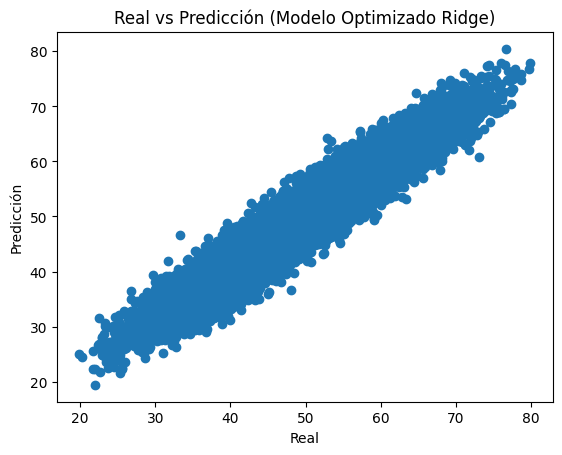

In [ ]:

import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


print("consumo_hogar.csv")
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
print("✅ Dataset cargado con éxito\n")
display(df.head())


df = df.dropna()

Q1 = df["Consumo_kWh"].quantile(0.25)
Q3 = df["Consumo_kWh"].quantile(0.75)
IQR = Q3 - Q1
df = df[(df["Consumo_kWh"] >= Q1 - 1.5*IQR) & (df["Consumo_kWh"] <= Q3 + 1.5*IQR)]

X = df[["Temperatura", "Personas", "Electrodomesticos"]]
y = df["Consumo_kWh"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)


model = Ridge(alpha=0.5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📌 RESULTADOS DEL MODELO OPTIMIZADO")
print("MSE:", mse)
print("R²:", r2)


plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción (Modelo Optimizado Ridge)")
plt.show()
